In [1]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = {"JAL4_3rdSept": JAL4_3rdSept,
        "JAL4_19thSept": JAL4_19thSept,
        "JAL4_28aug": JAL4_28aug,
        "JAL4_11thSept": JAL4_11thSept,
        "JAL5_8thSept": JAL005_8thSept,
        "JAL5_21stSept": JAL005_21stSept,
        "JAL6_28mar": JAL6_28mar, 
        "JAL6_flip4_21mar": JAL6_flip4_21mar, 
        "JAL6_flip3_18mar": JAL6_flip3_18mar, 
        "JAL6_flip5_25mar": JAL6_flip5_25mar, 
        "JAL7_sesh8_9apr": JAL7_sesh8_9apr, # almost no homings
        "JAL7_flip5_22mar": JAL7_flip5_22mar, 
        "JAL7_flip2_12mar": JAL7_flip2_12mar, 
        "JAL7_sesh9_16apr": JAL7_sesh9_16apr, 
        "JAL7_23apr": JAL7_23apr,
        "JAL8_flip1_25apr": JAL8_flip1_25apr, 
        "JAL8_flip2_29apr": JAL8_flip2_29apr, 
        "JAL8_flip3_7may": JAL8_flip3_7may, 
        "JAL8_14may": JAL8_14may, 
        "JAL8_flip4_10may": JAL8_flip4_10may}

In [17]:
%load_ext autoreload
%autoreload 2

from behave_analysis.process.process import Process
from settings.settings_overrides import settings_overrides
from behave_analysis.analyze.results_database_utils import check_database_for_same_run, settings_to_check
from settings.settings_analyze_efizz import Settings_ae
from behave_analysis.analyze.EscapePattern.escape_pattern_utils import compute_tuning_stat, define_bin_edges

import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import os

%matplotlib inline
cond_list = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
COLUMNS_TO_KEEP = ["hdir", "mouse_x_position", "mouse_y_position", "speed", "hsa", "h_preflipbar_a", "h_postflipbar_a", "distance_to_shelter", "distance_to_barrier1", "distance_to_barrier2"]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
"""Load behavioral data"""
session_name = list(experiments_objects.keys())[8]
exp = experiments_objects[session_name]
session = Process(exp).load_session()
session_start = max(session.shelter_time[0]*60*40, 30*40) # start at shelter_time or 30s, whichever is later
video_df = pl.read_csv(os.path.join(session.base_path, session.processed_path) + "\\" + "full_video_dataframe.csv")
fcm = np.load(os.path.join(session.base_path, session.processed_path) + "\\" + "frame_by_good_cluster_matrix.npy")
mean_fcm = np.nanmean(fcm, axis=0)
std_fcm = np.nanstd(fcm, axis=0)

2026-04-30 12:42:51.897 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


In [65]:
"""Load tuning data"""
var = "speed" # "distance_shelter", "bird_dist_shelter", "2D_position", "speed"

vars = ['escape in homing&escape']
if var != "2D_position":
    vars.extend([var + " in " + time_period for time_period in ["explore", "homing&escape"]])
vars.append("residual: escape in homing&escape - " + var + " in explore")

tuning_settings = {'ep_bins': 25,
                    'ep_no_stationary': False,
                    'ep_interpolation_mult': 2,
                    'ep_gaussian_fitting': False,
                    'ep_compute_loo_reliability': False,
                    'ep_tuned_compare_method': 'euclidean',
                    'ep_tuned_stats': 'bootstrap',
                    'ep_tuned_stats_samples': 100,
                    'linshift_min_step': 120,
                    'linshift_step': 80,
                    'linshift_step_n': 100,
                    'stim_type': 'audio',
                    'cluster_type': 'good',
                    'condition_types': 'experimental_conditions',
                    'compartment_split': ['all'],
                    'redo_compute': False}
Settings_ae = settings_overrides(Settings_ae, tuning_settings)

results_dict = {}
for v in vars:
    settings_dict = {"variable": v, **settings_to_check(Settings_ae, ["ep_"])}
    savepath = os.path.join(session.base_path, session.processed_path, "models", "escape_tuning")
        
    database, do_analysis, hexaname = check_database_for_same_run(settings_dict, 
                                                                    savepath + os.sep + "EscapePattern_results.csv", 
                                                                    Settings_ae)
    if not do_analysis:
        data_file = os.path.join(savepath, f"EPtuning_{hexaname}_results.npz")
        ep_data = np.load(data_file, allow_pickle=True)
        real_stat, shift_stat = compute_tuning_stat(stat='zscore_peak', 
                                                    shifted_matrix=ep_data['fr_shift'], 
                                                    shift0=int(np.shape(ep_data['fr_shift'])[0] / 2), 
                                                    neural_matrix=ep_data['neural_matrix'], 
                                                    condition=ep_data['condition'])
        sig_cells = real_stat > np.nanpercentile(shift_stat, 95, axis=0)
        results_dict[v] = {"real_stat": real_stat, "shift_stat": shift_stat, "sig_cells": sig_cells, "ep_data": ep_data}

# make condition vector
condition  = np.zeros(len(video_df))
condition[video_df["barrier_present"]] += 1
condition[video_df["barrier_flipped"]] += 1

2026-05-05 09:09:57.259 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 8 matched results in database: ['8e8a432d66a14068' 'bc5725c7599847ff' 'b9db35f6d6a24b67'
 '3321b7287c46482d' 'b3fd402bc7b84047' '34b38f8c3c0e42fb'
 '717ba3b0b2174ab1' '2e172a4b775444bc'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_barrier_flip2_2024_03_18T11_53_29\processed_data\models\escape_tuning\EscapePattern_results.csv
2026-05-05 09:12:18.249 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 2 matched results in database: ['7703411bb370419b' '559b4c40d24a464b'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_barrier_flip2_2024_03_18T11_53_29\processed_data\models\escape_tuning\EscapePattern_results.csv
2026-05-05 09:15:34.963 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 1 matched results in database: ['3928efdf8dfd4f04

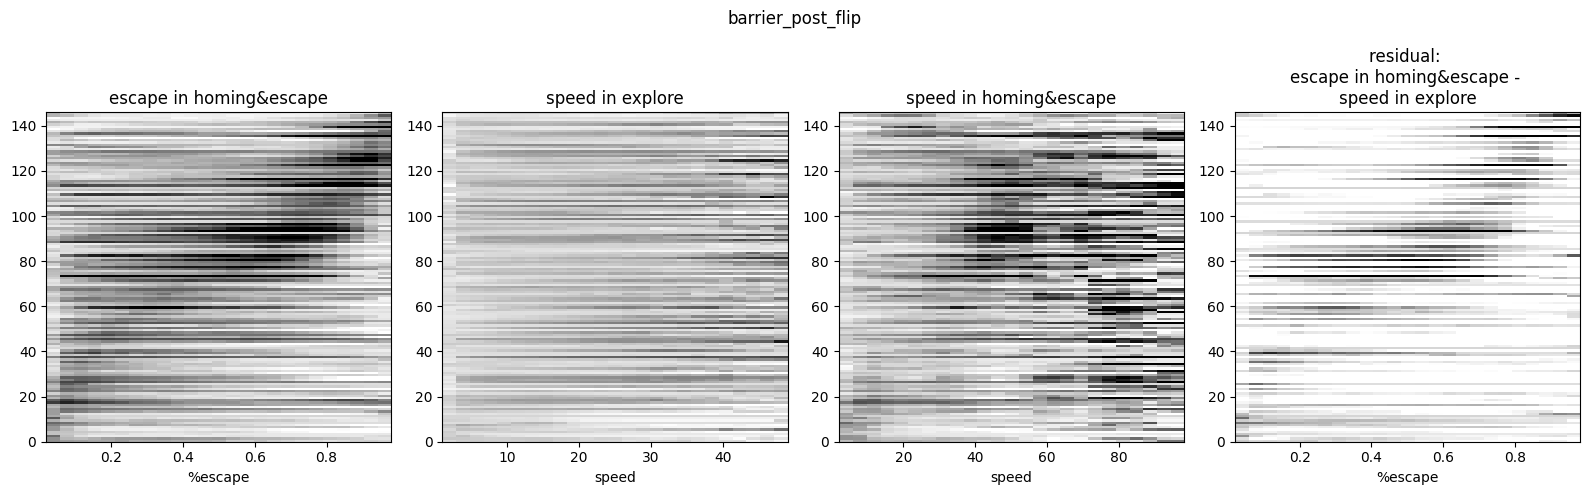

In [71]:
c = 2

tuned = np.where(results_dict["escape in homing&escape"]["sig_cells"][c,:] & results_dict["residual: escape in homing&escape - " + var + " in explore"]["sig_cells"][c,:])[0]

fig, axs = plt.subplots(1, len(results_dict.keys()), figsize=(4*len(results_dict.keys()), 5))
for i, v in enumerate(results_dict.keys()):
    tuning_hm = results_dict[v]["ep_data"]["fr_full"][c, tuned, :]
    tuning_hm = np.divide(tuning_hm - mean_fcm[tuned, np.newaxis],
                            std_fcm[tuned, np.newaxis],
                            out=np.zeros_like(tuning_hm, dtype=np.float64),
                            where=std_fcm[tuned, np.newaxis] != 0)
    if v == "escape in homing&escape":
        sort_idx = np.argsort(np.argmax(tuning_hm, axis=1))
    if "escape in" in v:
        bin_edges = results_dict[v]["ep_data"]["bin_edges"]
        # bin_edges = define_bin_edges(Settings_ae, "escape")
        axs[i].set_xlabel(r"%escape")
    else:
        bin_edges = results_dict[v]["ep_data"]["bin_edges"]
        # bin_edges = define_bin_edges(Settings_ae, var)
        axs[i].set_xlabel(var)
    bins = (bin_edges[:-1] + bin_edges[1:]) / 2
    axs[i].imshow(tuning_hm[sort_idx,:], aspect="auto", origin="lower", cmap="gray_r", vmin=-.5, vmax=2, interpolation="none", extent=[bins[0], bins[-1], 0, tuning_hm.shape[0]])
    if "residual" in v:
        axs[i].set_title("residual: \nescape in homing&escape - \n" + var + " in explore")
    else:
        axs[i].set_title(v)
fig.suptitle(cond_list[c])
fig.tight_layout()

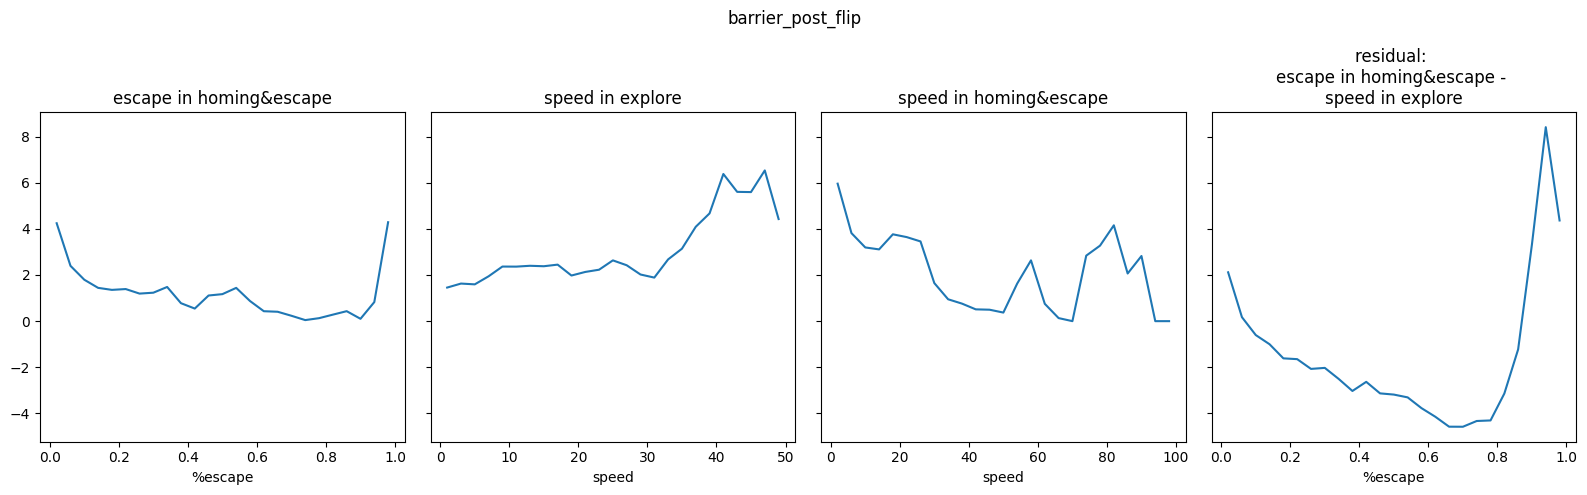

In [74]:
c = 2
n=-1
tuned = np.where(results_dict["escape in homing&escape"]["sig_cells"][c,:] & results_dict["residual: escape in homing&escape - " + var + " in explore"]["sig_cells"][c,:])[0]

fig, axs = plt.subplots(1, len(results_dict.keys()), figsize=(4*len(results_dict.keys()), 5), sharey=True)
for i, v in enumerate(results_dict.keys()):
    neur = results_dict[v]["ep_data"]["fr_full"][c, tuned, :]
    tuning_hm = np.divide(neur - mean_fcm[tuned, np.newaxis],
                            std_fcm[tuned, np.newaxis],
                            out=np.zeros_like(tuning_hm, dtype=np.float64),
                            where=std_fcm[tuned, np.newaxis] != 0)
    if v == "escape in homing&escape":
        sort_idx = np.argsort(np.argmax(tuning_hm, axis=1))
    if "escape in" in v:
        bin_edges = results_dict[v]["ep_data"]["bin_edges"]
        # bin_edges = define_bin_edges(Settings_ae, "escape")
        axs[i].set_xlabel(r"%escape")
    else:
        bin_edges = results_dict[v]["ep_data"]["bin_edges"]
        # bin_edges = define_bin_edges(Settings_ae, var)
        axs[i].set_xlabel(var)
    bins = (bin_edges[:-1] + bin_edges[1:]) / 2
    axs[i].plot(bins,neur[sort_idx[n],:])
    if "residual" in v:
        axs[i].set_title("residual: \nescape in homing&escape - \n" + var + " in explore")
    else:
        axs[i].set_title(v)
fig.suptitle(cond_list[c])
fig.tight_layout()

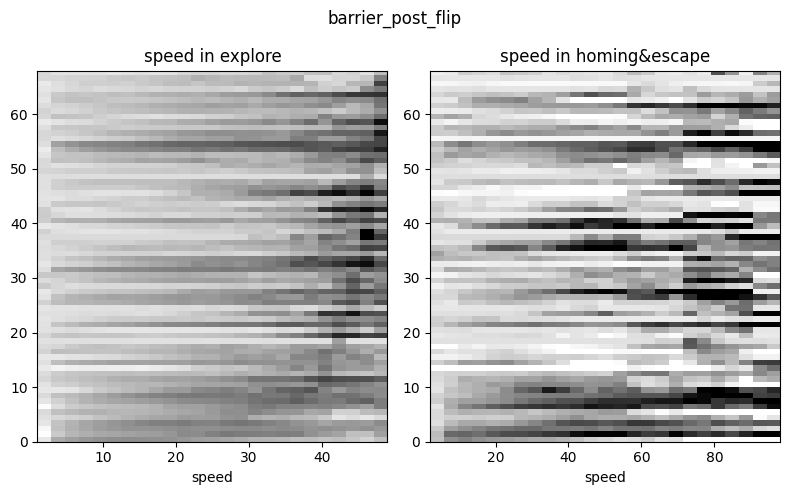

In [70]:
c = 2

tuned = np.where(results_dict[var + " in explore"]["sig_cells"][c,:])[0] #results_dict[var +" in homing&escape"]["sig_cells"][c,:])[0]
check_var = [var + " in explore", var +" in homing&escape"]
# check_var = results_dict.keys()

fig, axs = plt.subplots(1, len(check_var), figsize=(4*len(check_var), 5))
for i, v in enumerate(check_var):
    tuning_hm = results_dict[v]["ep_data"]["fr_full"][c, tuned, :]
    tuning_hm = np.divide(tuning_hm - mean_fcm[tuned, np.newaxis],
                            std_fcm[tuned, np.newaxis],
                            out=np.zeros_like(tuning_hm, dtype=np.float64),
                            where=std_fcm[tuned, np.newaxis] != 0)
    if i == 0:
        sort_idx = np.argsort(np.argmax(tuning_hm, axis=1))
    if "escape in" in v:
        bin_edges = results_dict[v]["ep_data"]["bin_edges"]
        # bin_edges = define_bin_edges(Settings_ae, "escape")
        axs[i].set_xlabel(r"%escape")
    else:
        bin_edges = results_dict[v]["ep_data"]["bin_edges"]
        # bin_edges = define_bin_edges(Settings_ae, var)
        axs[i].set_xlabel(var)
    bins = (bin_edges[:-1] + bin_edges[1:]) / 2
    axs[i].imshow(tuning_hm[sort_idx,:], aspect="auto", origin="lower", cmap="gray_r", vmin=-.5, vmax=2, interpolation="none", extent=[bins[0], bins[-1], 0, tuning_hm.shape[0]])
    if "residual" in v:
        axs[i].set_title("residual: \nescape in homing&escape - \n" + var + " in explore")
    else:
        axs[i].set_title(v)
fig.suptitle(cond_list[c])
fig.tight_layout()